# Initial EDA - Customer Info

This notebook starts the initial exploratory data analysis for the customer segmentation project.

This phase focuses only on `customer_info`, the customer-level dataset that will be the base for segmentation because every customer must be included in the final clustering output.

## Imports and Data Loading

Load the raw CSV files directly with `pd.read_csv` from `../data/raw/`. No working-directory changes or fallback paths are used.

In [1]:
import ast

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [2]:
customer_info = pd.read_csv("../data/raw/customer_info.csv")
customer_info.head()

,customer_id,customer_name,customer_gender,customer_birthdate,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,...,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,loyalty_card_number,latitude,longitude
0,3,Bsc. Crystal Kitchens,female,02/12/1970 01:36 PM,1.0,1.0,1.0,3.0,11731.0,4553.0,...,213.0,552.0,256.0,384.0,189.0,0.631599,2020.0,1.0,38.794428,-9.215739
1,4,Bsc. Glenda Bauman,female,11/13/1975 06:58 PM,1.0,0.0,0.0,2.0,13694.0,963.0,...,15.0,1880.0,333.0,665.0,130.0,0.149890,2013.0,1.0,38.751711,-9.179611
2,5,Msc. Antonio Campbell,male,09/10/1971 10:07 AM,0.0,0.0,NaN,2.0,12407.0,0.0,...,273.0,507.0,101.0,222.0,81.0,0.069126,2005.0,NaN,38.780678,-9.160656
3,7,John Kelling,male,10/23/1982 11:20 AM,0.0,0.0,2.0,1.0,7493.0,1105.0,...,1083.0,485.0,1656.0,184.0,92.0,0.253609,2021.0,1.0,38.739548,-9.148679
4,8,Arthur Dematteo,male,08/04/1969 10:22 PM,0.0,0.0,3.0,1.0,9187.0,10841.0,...,1015.0,297.0,1258.0,441.0,6.0,0.186569,2021.0,1.0,38.733071,-9.188188


## Basic Structure

Check the size, columns, data types, and summary statistics before making any assumptions about the data.

In [3]:
print(f"Rows: {customer_info.shape[0]:,}")
print(f"Columns: {customer_info.shape[1]:,}")

customer_info.columns.to_frame(index=False, name="column")

Rows: 33,038
Columns: 25


,column
0,customer_id
1,customer_name
2,customer_gender
3,customer_birthdate
4,kids_home
5,teens_home
6,number_complaints
7,distinct_stores_visited
8,lifetime_spend_groceries
9,lifetime_spend_electronics


In [4]:
customer_info.dtypes.to_frame(name="dtype")

,dtype
customer_id,int64
customer_name,object
customer_gender,object
customer_birthdate,object
kids_home,float64
teens_home,float64
number_complaints,float64
distinct_stores_visited,float64
lifetime_spend_groceries,float64
lifetime_spend_electronics,float64


In [5]:
customer_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33038 entries, 0 to 33037
Data columns (total 25 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   customer_id                              33038 non-null  int64  
 1   customer_name                            33038 non-null  object 
 2   customer_gender                          33038 non-null  object 
 3   customer_birthdate                       32873 non-null  object 
 4   kids_home                                32708 non-null  float64
 5   teens_home                               32708 non-null  float64
 6   number_complaints                        32377 non-null  float64
 7   distinct_stores_visited                  32708 non-null  float64
 8   lifetime_spend_groceries                 33038 non-null  float64
 9   lifetime_spend_electronics               32377 non-null  float64
 10  typical_hour                             32377

In [6]:
customer_info.describe()

,customer_id,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,...,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,loyalty_card_number,latitude,longitude
count,33038.000000,32708.000000,32708.000000,32377.000000,32708.000000,33038.000000,32377.000000,32377.000000,32377.000000,33038.000000,...,32047.000000,32708.00000,32377.000000,32377.000000,33038.000000,32708.000000,33038.000000,19932.0,33038.000000,33038.000000
mean,19974.265785,1.116118,0.898893,0.930846,3.167941,16306.227798,2763.080088,12.659388,727.223801,464.352776,...,608.781228,820.34646,373.900917,336.217099,148.914644,0.318866,2015.311853,1.0,38.749694,-9.154549
std,11538.538632,1.150186,0.962924,0.894658,1.674114,11985.903518,3453.191495,4.854708,654.633087,275.767976,...,497.068874,608.31732,460.782042,160.234980,105.922907,0.283638,5.032196,0.0,0.022498,0.028581
min,3.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,6.000000,0.000000,0.000000,...,0.000000,0.00000,0.000000,0.000000,0.000000,-1.274940,1993.000000,1.0,38.687987,-9.232989
25%,9985.250000,0.000000,0.000000,0.000000,2.000000,8647.000000,579.000000,8.000000,224.000000,241.000000,...,171.000000,362.00000,125.000000,225.000000,67.000000,0.122359,2012.000000,1.0,38.734079,-9.173732
50%,19951.500000,1.000000,1.000000,1.000000,3.000000,13002.500000,1470.000000,12.000000,471.000000,421.000000,...,511.000000,686.00000,223.000000,327.000000,123.000000,0.239449,2015.000000,1.0,38.748286,-9.156689
75%,29964.750000,1.000000,1.000000,1.000000,4.000000,20807.000000,3745.000000,16.000000,1074.000000,640.000000,...,923.000000,1120.00000,374.000000,435.000000,210.000000,0.469390,2019.000000,1.0,38.765779,-9.139608
max,40000.000000,8.000000,6.000000,7.000000,10.000000,104670.000000,35299.000000,23.000000,3337.000000,2180.000000,...,3172.000000,3482.00000,3936.000000,1224.000000,600.000000,1.000000,2029.000000,1.0,38.823693,-9.035697


In [7]:
customer_info.select_dtypes(include=["object", "string"]).describe()

,customer_name,customer_gender,customer_birthdate
count,33038,33038,32873
unique,32543,2,32852
top,Susan Smith,female,05/19/1973 08:31 AM
freq,5,16577,2


## Key Integrity Checks

`customer_id` must be reliable because the final output needs one assigned cluster for every customer.

In [8]:
customer_id_checks = pd.DataFrame(
    {
        "check": [
            "duplicated customer_id count",
            "unique customer_id count",
            "customer_id is unique",
        ],
        "value": [
            customer_info["customer_id"].duplicated().sum(),
            customer_info["customer_id"].nunique(dropna=False),
            customer_info["customer_id"].is_unique,
        ],
    }
)

customer_id_checks

,check,value
0,duplicated customer_id count,0
1,unique customer_id count,33038
2,customer_id is unique,True


## Missing Values

Review missingness by column before deciding how to handle any values later.

In [9]:
missing_summary = pd.DataFrame(
    {
        "missing_count": customer_info.isna().sum(),
        "missing_percentage": customer_info.isna().mean() * 100,
    }
).sort_values("missing_percentage", ascending=False)

missing_summary

,missing_count,missing_percentage
loyalty_card_number,13106,39.669472
lifetime_spend_fish,991,2.999576
lifetime_spend_videogames,661,2.000726
typical_hour,661,2.000726
lifetime_spend_meat,661,2.000726
lifetime_spend_electronics,661,2.000726
lifetime_spend_vegetables,661,2.000726
lifetime_spend_petfood,661,2.000726
number_complaints,661,2.000726
lifetime_spend_alcohol_drinks,330,0.998850


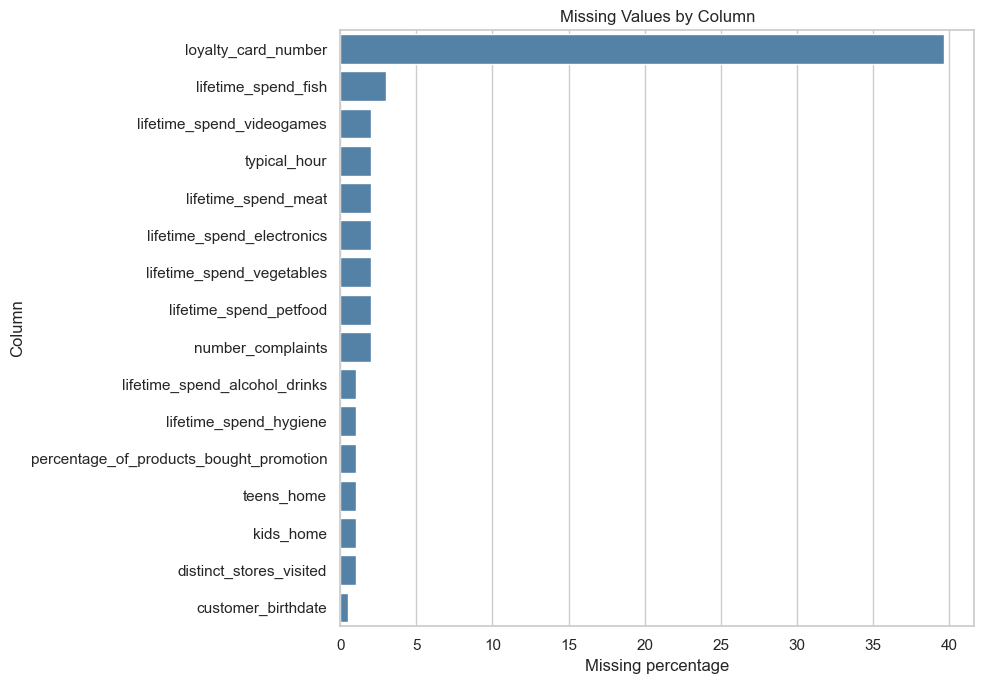

In [10]:
missing_with_values = missing_summary[missing_summary["missing_count"] > 0].reset_index(names="column")

if missing_with_values.empty:
    print("No missing values found.")
else:
    plt.figure(figsize=(10, 7))
    sns.barplot(
        data=missing_with_values,
        x="missing_percentage",
        y="column",
        color="steelblue",
    )
    plt.title("Missing Values by Column")
    plt.xlabel("Missing percentage")
    plt.ylabel("Column")
    plt.tight_layout()
    plt.show()

Missingness is concentrated in `loyalty_card_number`, while several customer behavior fields have smaller missing shares. These columns should be handled carefully later, but no imputation or preprocessing is done in this notebook.

## Numerical Distributions

Plot the main numerical fields that may matter for customer segmentation. This is only inspection, not feature engineering.

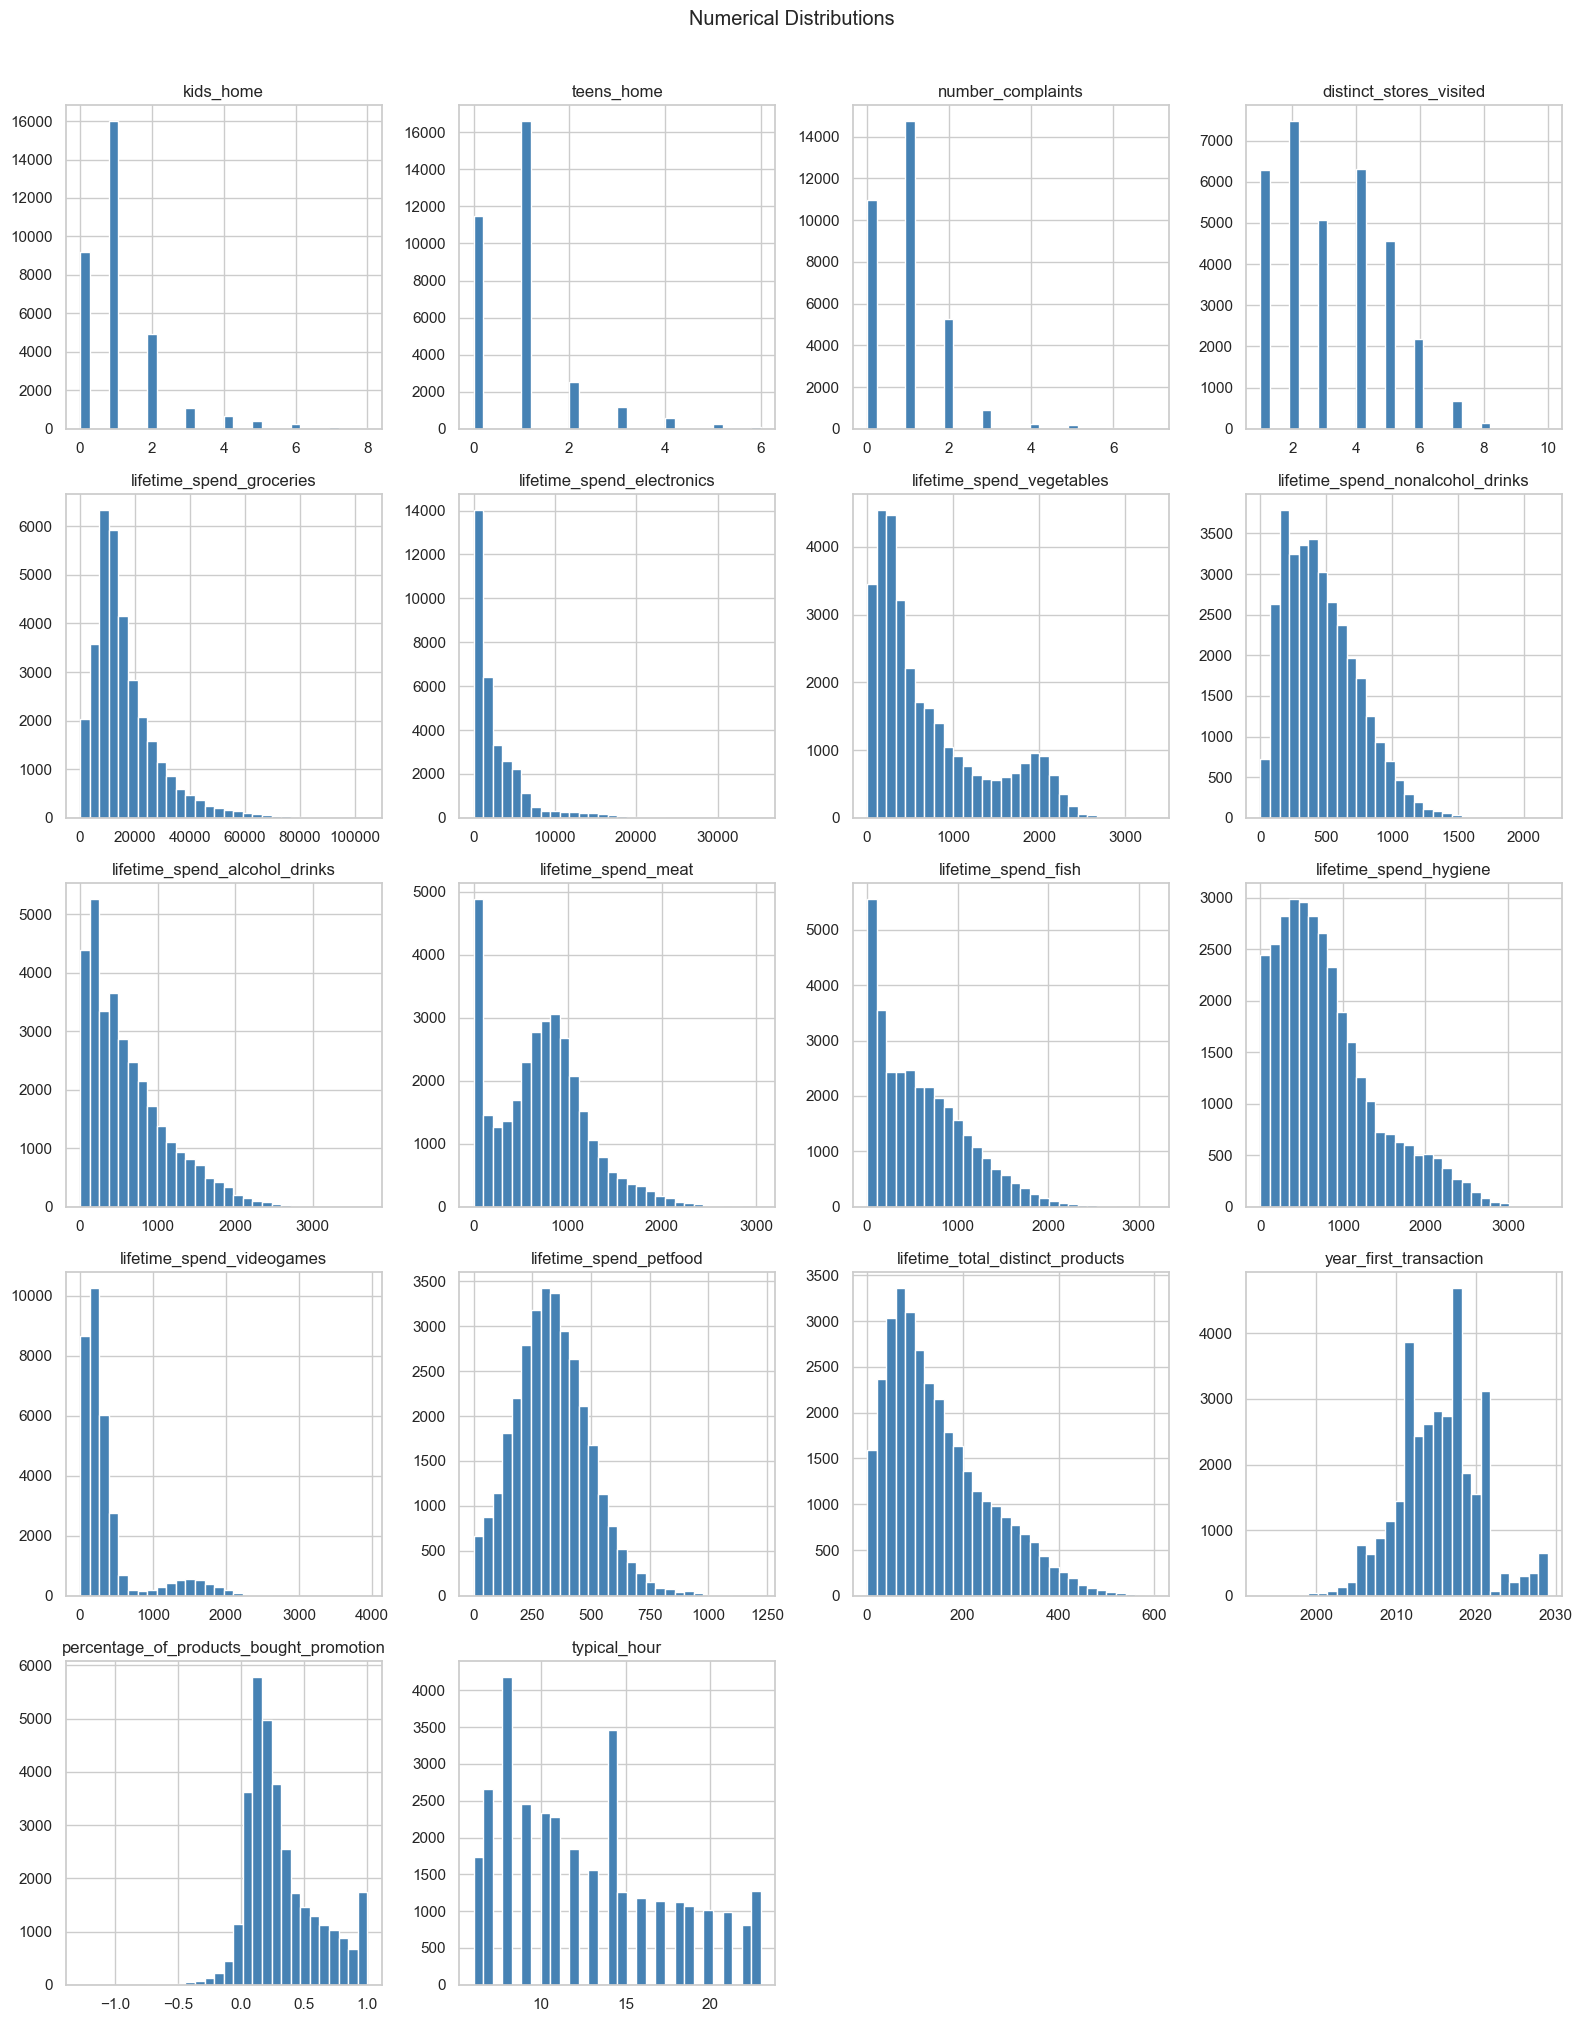

In [11]:
lifetime_spend_columns = [column for column in customer_info.columns if column.startswith("lifetime_spend_")]

numerical_columns = [
    "kids_home",
    "teens_home",
    "number_complaints",
    "distinct_stores_visited",
    *lifetime_spend_columns,
    "lifetime_total_distinct_products",
    "year_first_transaction",
    "percentage_of_products_bought_promotion",
    "typical_hour",
]
numerical_columns = [column for column in dict.fromkeys(numerical_columns) if column in customer_info.columns]

customer_info[numerical_columns].hist(bins=30, figsize=(16, 20), color="steelblue", edgecolor="white")
plt.suptitle("Numerical Distributions", y=1.01)
plt.tight_layout()
plt.show()

Spend columns appear right-skewed, which is common for customer purchasing data. Range checks below are more important at this stage than reshaping distributions.

## Categorical Distributions

Inspect simple categorical fields and visible name prefixes.

In [12]:
customer_info["customer_gender"].value_counts(dropna=False)

customer_gender
female    16577
male      16461
Name: count, dtype: int64

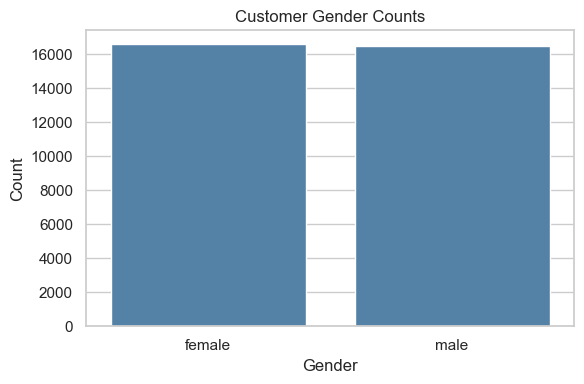

In [13]:
plt.figure(figsize=(6, 4))
sns.countplot(data=customer_info, x="customer_gender", color="steelblue")
plt.title("Customer Gender Counts")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [14]:
customer_info["loyalty_card_number"].value_counts(dropna=False)

loyalty_card_number
1.0    19932
NaN    13106
Name: count, dtype: int64

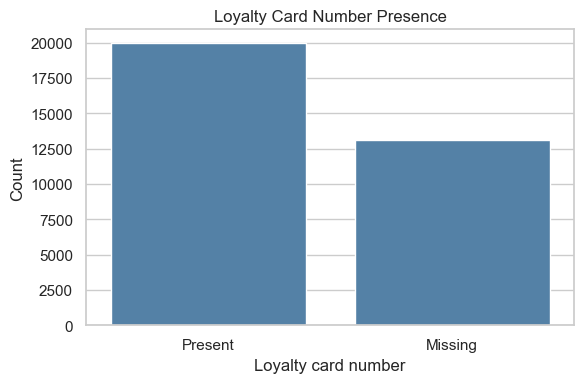

In [15]:
loyalty_status = customer_info["loyalty_card_number"].map({1.0: "Present"}).fillna("Missing")
loyalty_status_counts = loyalty_status.value_counts()

plt.figure(figsize=(6, 4))
sns.barplot(x=loyalty_status_counts.index, y=loyalty_status_counts.values, color="steelblue")
plt.title("Loyalty Card Number Presence")
plt.xlabel("Loyalty card number")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [16]:
name_prefix_counts = (
    customer_info["customer_name"]
    .astype("string")
    .str.extract(r"^(Bsc\.|Msc\.|Phd\.)", expand=False)
    .fillna("No visible prefix")
    .value_counts()
)

name_prefix_counts

customer_name
No visible prefix    17731
Bsc.                  5154
Phd.                  5096
Msc.                  5057
Name: count, dtype: Int64

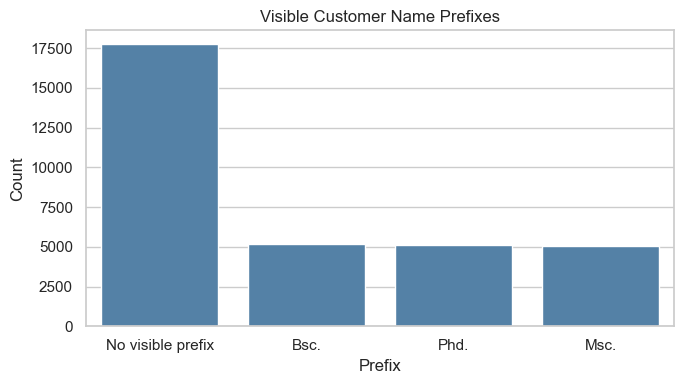

In [17]:
plt.figure(figsize=(7, 4))
sns.barplot(x=name_prefix_counts.index, y=name_prefix_counts.values, color="steelblue")
plt.title("Visible Customer Name Prefixes")
plt.xlabel("Prefix")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

Gender is balanced. `loyalty_card_number` looks more like an indicator than a meaningful numeric value, and the name prefix inspection is only a possible clue for later feature engineering.

## Data Quality Checks

Check for suspicious ranges without changing the data.

In [18]:
promotion = customer_info["percentage_of_products_bought_promotion"]
year_first_transaction = customer_info["year_first_transaction"]
typical_hour = customer_info["typical_hour"]

range_checks = pd.DataFrame(
    {
        "check": [
            "promotion percentage outside [0, 1]",
            "year_first_transaction after 2026",
            "typical_hour outside [0, 23]",
            "negative kids_home",
            "negative teens_home",
            "negative number_complaints",
            "negative distinct_stores_visited",
        ],
        "count": [
            ((promotion < 0) | (promotion > 1)).sum(),
            (year_first_transaction > 2026).sum(),
            ((typical_hour < 0) | (typical_hour > 23)).sum(),
            (customer_info["kids_home"] < 0).sum(),
            (customer_info["teens_home"] < 0).sum(),
            (customer_info["number_complaints"] < 0).sum(),
            (customer_info["distinct_stores_visited"] < 0).sum(),
        ],
    }
)

range_checks

,check,count
0,"promotion percentage outside [0, 1]",1755
1,year_first_transaction after 2026,991
2,"typical_hour outside [0, 23]",0
3,negative kids_home,0
4,negative teens_home,0
5,negative number_complaints,0
6,negative distinct_stores_visited,0


In [19]:
spend_and_count_columns = lifetime_spend_columns + ["lifetime_total_distinct_products"]
negative_value_counts = customer_info[spend_and_count_columns].lt(0).sum().sort_values(ascending=False)

negative_value_counts[negative_value_counts > 0]

Series([], dtype: int64)

## Data Quality Notes

- Missing values are present, especially in `loyalty_card_number`; smaller missing shares also appear in several behavior and spend fields.
- Possible invalid values should be reviewed before preprocessing, especially promotion percentages outside `[0, 1]`.
- `loyalty_card_number` may be better treated as a loyalty flag later because the visible non-missing value is `1.0`.
- `customer_name` should not be used directly for modelling.
- Degree prefixes such as `Bsc.`, `Msc.`, and `Phd.` may become a useful engineered feature later, but no feature is created here.
- `year_first_transaction` includes suspicious future-looking values after 2026 that should be validated.
- `percentage_of_products_bought_promotion` includes invalid negative values and should be reviewed before modelling.

# Customer Basket Initial EDA

This section reviews the transaction-level `customer_basket` dataset. It keeps the work to initial inspection only: no preprocessing, modelling, or association rules.

## Customer Basket Data Loading

Load the raw CSV directly from the project data folder.

In [20]:
customer_basket = pd.read_csv("../data/raw/customer_basket.csv")
customer_basket.head()

,invoice_id,list_of_goods,customer_id
0,3700630,"['chicken', 'rice', 'pepper', 'whole wheat ric...",12912
1,10242376,"['low fat yogurt', 'tomatoes', 'pepper', 'aspa...",22853
2,91550,"['cake', 'tomatoes', 'pancakes', 'iPad', 'fina...",19
3,3137503,"['cereals', 'megaman zero', 'final fantasy XIX...",10995
4,7165061,"['rice', 'frozen smoothie', 'black tea', 'tea'...",27807


## Basic Structure

Check the size, columns, data types, and summary statistics before making assumptions about basket-level data.

In [21]:
print(f"Rows: {customer_basket.shape[0]:,}")
print(f"Columns: {customer_basket.shape[1]:,}")

customer_basket.columns.to_frame(index=False, name="column")

Rows: 100,000
Columns: 3


,column
0,invoice_id
1,list_of_goods
2,customer_id


In [22]:
customer_basket.dtypes.to_frame(name="dtype")

,dtype
invoice_id,int64
list_of_goods,object
customer_id,int64


In [23]:
customer_basket.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 3 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   invoice_id     100000 non-null  int64 
 1   list_of_goods  100000 non-null  object
 2   customer_id    100000 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 2.3+ MB


In [24]:
customer_basket.head()

,invoice_id,list_of_goods,customer_id
0,3700630,"['chicken', 'rice', 'pepper', 'whole wheat ric...",12912
1,10242376,"['low fat yogurt', 'tomatoes', 'pepper', 'aspa...",22853
2,91550,"['cake', 'tomatoes', 'pancakes', 'iPad', 'fina...",19
3,3137503,"['cereals', 'megaman zero', 'final fantasy XIX...",10995
4,7165061,"['rice', 'frozen smoothie', 'black tea', 'tea'...",27807


In [25]:
customer_basket.describe(include="all")

,invoice_id,list_of_goods,customer_id
count,1.000000e+05,100000,100000.000000
unique,NaN,99784,NaN
top,NaN,"['energy bar', 'airpods']",NaN
freq,NaN,5,NaN
mean,6.155483e+06,NaN,20034.595410
std,3.532964e+06,NaN,11546.142217
min,2.002300e+04,NaN,3.000000
25%,3.111465e+06,NaN,10026.000000
50%,6.162339e+06,NaN,20018.000000
75%,9.212399e+06,NaN,30047.000000


## Integrity Checks

Check invoice and row uniqueness before using baskets for customer-level analysis.

In [26]:
basket_integrity_checks = pd.DataFrame(
    {
        "check": [
            "duplicated invoice_id count",
            "unique invoice_id count",
            "invoice_id is unique",
            "unique customer_id count",
            "duplicated full rows count",
        ],
        "value": [
            customer_basket["invoice_id"].duplicated().sum(),
            customer_basket["invoice_id"].nunique(dropna=False),
            customer_basket["invoice_id"].is_unique,
            customer_basket["customer_id"].nunique(dropna=False),
            customer_basket.duplicated().sum(),
        ],
    }
)

basket_integrity_checks

,check,value
0,duplicated invoice_id count,0
1,unique invoice_id count,100000
2,invoice_id is unique,True
3,unique customer_id count,28127
4,duplicated full rows count,0


## Missing Values

Review missingness by column before deciding whether any cleaning will be needed later.

In [27]:
basket_missing_summary = pd.DataFrame(
    {
        "missing_count": customer_basket.isna().sum(),
        "missing_percentage": customer_basket.isna().mean() * 100,
    }
).sort_values("missing_percentage", ascending=False)

basket_missing_summary

,missing_count,missing_percentage
invoice_id,0,0.0
list_of_goods,0,0.0
customer_id,0,0.0


## Parse List of Goods

Parse `list_of_goods` into a temporary analysis column while preserving the original raw string column.

In [28]:
customer_basket["goods_list"] = customer_basket["list_of_goods"].apply(ast.literal_eval)
customer_basket[["list_of_goods", "goods_list"]].head()

,list_of_goods,goods_list
0,"['chicken', 'rice', 'pepper', 'whole wheat ric...","[chicken, rice, pepper, whole wheat rice, shri..."
1,"['low fat yogurt', 'tomatoes', 'pepper', 'aspa...","[low fat yogurt, tomatoes, pepper, asparagus, ..."
2,"['cake', 'tomatoes', 'pancakes', 'iPad', 'fina...","[cake, tomatoes, pancakes, iPad, final fantasy..."
3,"['cereals', 'megaman zero', 'final fantasy XIX...","[cereals, megaman zero, final fantasy XIX, honey]"
4,"['rice', 'frozen smoothie', 'black tea', 'tea'...","[rice, frozen smoothie, black tea, tea, minecr..."


## Basket Size Analysis

Count the number of products in each parsed basket for initial distribution checks.

In [29]:
customer_basket["basket_size"] = customer_basket["goods_list"].str.len()
customer_basket["basket_size"].describe()

count    100000.000000
mean          9.399750
std           3.824795
min           1.000000
25%           6.000000
50%           9.000000
75%          12.000000
max          18.000000
Name: basket_size, dtype: float64

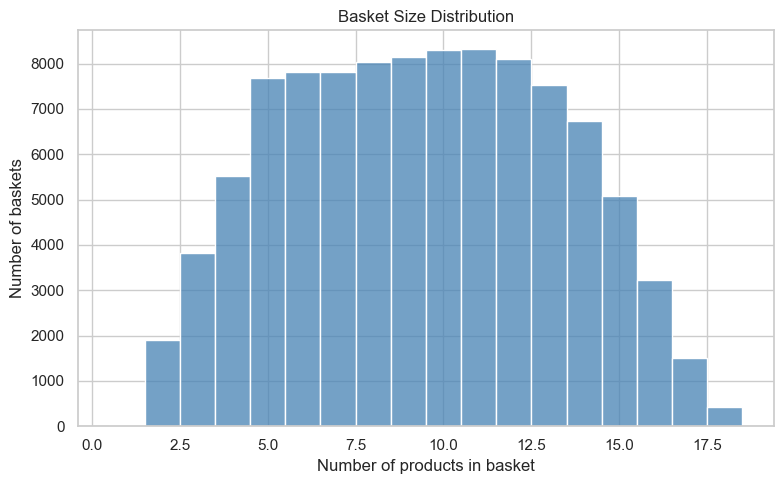

In [30]:
plt.figure(figsize=(8, 5))
sns.histplot(customer_basket["basket_size"], discrete=True, color="steelblue")
plt.title("Basket Size Distribution")
plt.xlabel("Number of products in basket")
plt.ylabel("Number of baskets")
plt.tight_layout()
plt.show()

Basket sizes range from 1 to 18 products and are centered around 9 products, which looks reasonable for initial basket-level analysis.

## Product Frequency Analysis

Explode the parsed lists to inspect individual product frequency across all baskets.

In [31]:
basket_products = customer_basket["goods_list"].explode()
print(f"Total unique products: {basket_products.nunique():,}")

Total unique products: 164


In [32]:
top_20_products = basket_products.value_counts().head(20)
top_20_products

goods_list
asparagus               12811
airpods                 12145
cereals                  9952
fresh bread              9934
butter                   9654
eggs                     9241
protein bar              8695
cooking oil              8623
toilet paper             8395
babies food              8318
dog food                 8192
energy bar               8117
milk                     8046
toothpaste               7973
oatmeal                  7794
energy drink             7525
tomatoes                 7460
napkins                  7342
bluetooth headphones     7279
green tea                7139
Name: count, dtype: int64

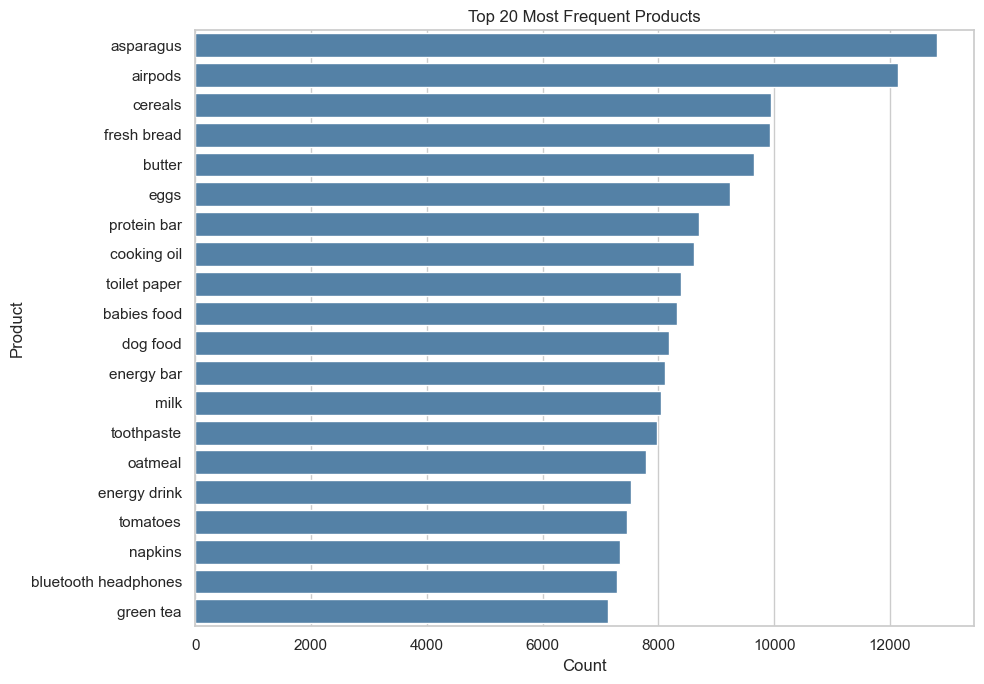

In [33]:
plt.figure(figsize=(10, 7))
sns.barplot(x=top_20_products.values, y=top_20_products.index, color="steelblue")
plt.title("Top 20 Most Frequent Products")
plt.xlabel("Count")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

There are 164 unique products. A few products appear much more often than others, especially `asparagus` and `airpods`, so product imbalance should be kept in mind later.

## Customer Transaction Frequency

Count how many baskets appear for each customer in `customer_basket`.

In [34]:
baskets_per_customer = customer_basket["customer_id"].value_counts()
baskets_per_customer.describe()

count    28127.000000
mean         3.555303
std          2.773821
min          1.000000
25%          1.000000
50%          3.000000
75%          5.000000
max         33.000000
Name: count, dtype: float64

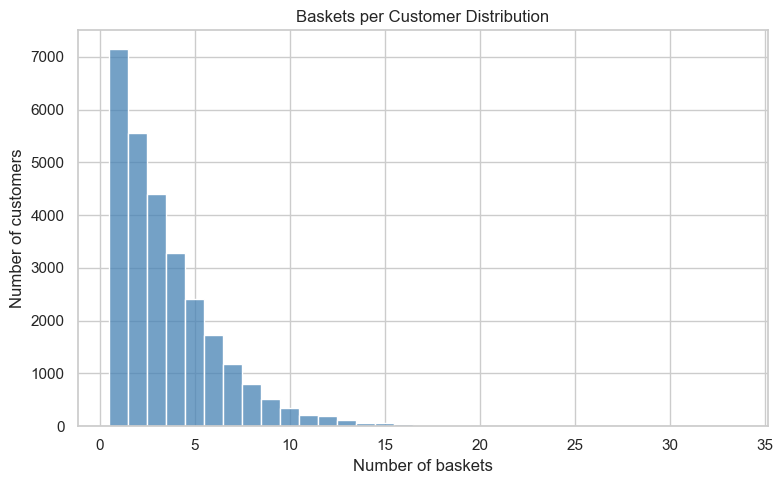

In [35]:
plt.figure(figsize=(8, 5))
sns.histplot(baskets_per_customer, discrete=True, color="steelblue")
plt.title("Baskets per Customer Distribution")
plt.xlabel("Number of baskets")
plt.ylabel("Number of customers")
plt.tight_layout()
plt.show()

In [36]:
top_10_customers_by_baskets = baskets_per_customer.head(10).rename_axis("customer_id").reset_index(name="basket_count")
top_10_customers_by_baskets

,customer_id,basket_count
0,17258,33
1,35828,27
2,29930,26
3,18492,25
4,36171,24
5,329,24
6,35134,23
7,21890,23
8,30574,23
9,8553,22


Most customers have only a few baskets in this dataset, while a small number of customers have much higher transaction counts.

## Customer Basket Data Quality Notes

- `invoice_id` appears unique in `customer_basket`; no duplicate invoice IDs were found.
- `customer_basket` has no missing values in the available columns.
- `list_of_goods` parses successfully into Python lists using `ast.literal_eval`, while the original raw column is preserved.
- Basket sizes look reasonable for initial inspection, ranging from 1 to 18 products.
- Some products dominate the transaction counts, with `asparagus` and `airpods` clearly leading the top-frequency table.
- Customer-level integration with `customer_info` will be checked in the next phase.

# Dataset Relationship Validation

Validate how `customer_info` and `customer_basket` connect through `customer_id`. This remains initial EDA only; no feature engineering dataset is saved.

## Customer ID Set Checks

Compare the customer ID sets to confirm whether basket records can be linked back to the customer-level table.

In [37]:
customer_info_ids = set(customer_info["customer_id"])
customer_basket_ids = set(customer_basket["customer_id"])

customer_ids_in_both = customer_info_ids.intersection(customer_basket_ids)
customer_ids_basket_not_info = customer_basket_ids.difference(customer_info_ids)
customer_ids_info_not_basket = customer_info_ids.difference(customer_basket_ids)

customer_id_relationship_checks = pd.DataFrame(
    {
        "check": [
            "unique customer_id in customer_info",
            "unique customer_id in customer_basket",
            "customer_id present in both datasets",
            "customer_id in customer_basket but not customer_info",
            "customer_id in customer_info but not customer_basket",
        ],
        "value": [
            len(customer_info_ids),
            len(customer_basket_ids),
            len(customer_ids_in_both),
            len(customer_ids_basket_not_info),
            len(customer_ids_info_not_basket),
        ],
    }
)

customer_id_relationship_checks

,check,value
0,unique customer_id in customer_info,33038
1,unique customer_id in customer_basket,28127
2,customer_id present in both datasets,28127
3,customer_id in customer_basket but not custome...,0
4,customer_id in customer_info but not customer_...,4911


## Integrity Conclusion

Confirm whether every transaction-level customer ID exists in the customer-level dataset.

In [38]:
all_basket_customers_in_info = len(customer_ids_basket_not_info) == 0
print(f"Every customer_id in customer_basket exists in customer_info: {all_basket_customers_in_info}")

Every customer_id in customer_basket exists in customer_info: True


Every `customer_id` in `customer_basket` exists in `customer_info`, so basket records can be safely linked to customer records. This matters because future customer-level analysis must not introduce transactions that cannot be assigned back to a known customer.

## Coverage Analysis

Measure how many customers in `customer_info` have at least one basket record.

In [39]:
customer_basket_coverage = pd.DataFrame(
    {
        "coverage_status": ["customers_with_basket", "customers_without_basket"],
        "count": [len(customer_ids_in_both), len(customer_ids_info_not_basket)],
    }
)
customer_basket_coverage["percentage"] = (
    customer_basket_coverage["count"] / len(customer_info_ids) * 100
)

customer_basket_coverage

,coverage_status,count,percentage
0,customers_with_basket,28127,85.135299
1,customers_without_basket,4911,14.864701


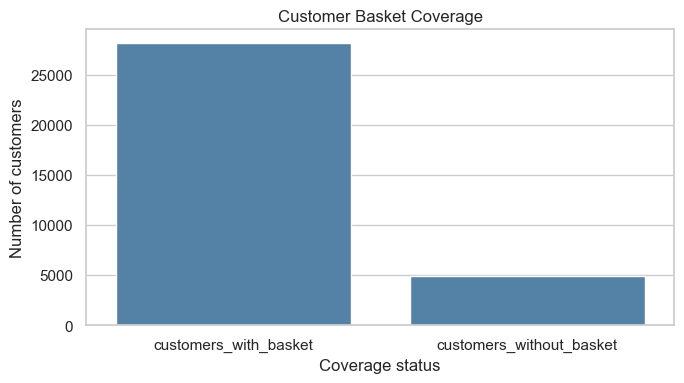

In [40]:
plt.figure(figsize=(7, 4))
sns.barplot(data=customer_basket_coverage, x="coverage_status", y="count", color="steelblue")
plt.title("Customer Basket Coverage")
plt.xlabel("Coverage status")
plt.ylabel("Number of customers")
plt.tight_layout()
plt.show()

Most customers in `customer_info` have at least one basket record, but a meaningful minority do not. Those customers still need to remain in the final customer-level dataset.

## Transaction Count Merge for Analysis Only

Create a temporary basket count summary and merge it into `customer_info` only for inspection.

In [41]:
basket_counts = (
    customer_basket
    .groupby("customer_id")
    .size()
    .reset_index(name="basket_count")
)

customer_info_with_basket_counts = customer_info.merge(basket_counts, on="customer_id", how="left")
customer_info_with_basket_counts["basket_count"] = (
    customer_info_with_basket_counts["basket_count"].fillna(0).astype(int)
)

customer_info_with_basket_counts[["customer_id", "basket_count"]].head()

,customer_id,basket_count
0,3,2
1,4,2
2,5,1
3,7,1
4,8,0


In [42]:
customer_info_with_basket_counts["basket_count"].describe()

count    33038.000000
mean         3.026818
std          2.854824
min          0.000000
25%          1.000000
50%          2.000000
75%          4.000000
max         33.000000
Name: basket_count, dtype: float64

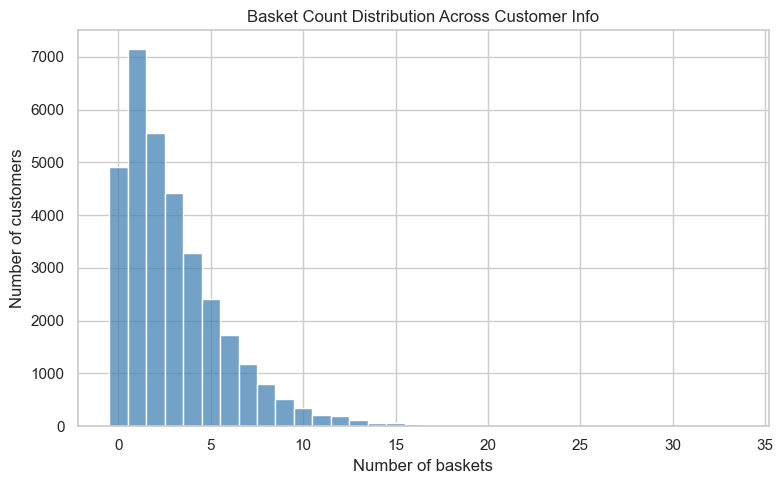

In [43]:
plt.figure(figsize=(8, 5))
sns.histplot(customer_info_with_basket_counts["basket_count"], discrete=True, color="steelblue")
plt.title("Basket Count Distribution Across Customer Info")
plt.xlabel("Number of baskets")
plt.ylabel("Number of customers")
plt.tight_layout()
plt.show()

## Relationship Data Quality Notes

- `customer_basket` can be safely linked to `customer_info` because every basket customer ID appears in the customer-level table.
- Some `customer_info` customers do not have basket records; in this data, 4,911 customers have no matching basket.
- Final clustering must still include every `customer_id` from `customer_info`, including customers without transaction records.
- Basket-derived features should be handled carefully later because not every customer has basket data.
- The next phase will define data quality decisions before feature engineering.

# Data Quality Decisions Before Feature Engineering

This section records the main data quality decisions that will guide feature engineering. No preprocessing, modelling, or saved feature table is created here.

## Missing Values

- Missing values will not be dropped blindly.
- Treatment will depend on the meaning of each column.
- Numerical spend and behavior features will likely use median values, or zero where zero has clear business meaning.
- Basket-derived missing values for customers without baskets should become `0` for count-based features later.

## `loyalty_card_number`

- `loyalty_card_number` should not be used as a raw number.
- It should become a binary `has_loyalty_card` feature later.
- Missing values likely indicate no loyalty card, unless later evidence suggests otherwise.

## `customer_name`

- `customer_name` should not be used directly for modelling.
- It may contain academic prefixes such as `Bsc.`, `Msc.`, and `Phd.`.
- Prefixes may be extracted into a simple `degree_level` feature later if useful.

## `year_first_transaction`

- `year_first_transaction` should not be used raw without caution.
- It should likely become customer tenure.
- Suspicious or future-looking years should be checked and handled during feature engineering or preprocessing.

## `percentage_of_products_bought_promotion`

- `percentage_of_products_bought_promotion` should be checked for invalid values outside a valid percentage range.
- Invalid values should be handled before modelling.
- It may become an important proxy for promotion sensitivity.

## Location Columns

- `latitude` and `longitude` should be considered carefully.
- They may help geographic segmentation, but can also dominate distance-based clustering if not scaled properly.
- For a first modelling baseline, they may be excluded or tested separately.

## Basket Coverage

- `customer_basket` links safely to `customer_info` because all basket customer IDs exist in the customer-level table.
- Some `customer_info` customers have no basket records.
- Basket-derived features must be created carefully so every customer remains in the final dataset.
- Count-based basket features can be filled with `0` for customers without basket records.

## Modelling Implication

- The base clustering dataset should start from `customer_info`.
- `customer_basket` should enrich the analysis, cluster profiling, and promotions.
- The final output must include every `customer_id`.

The next phase is feature engineering, where these decisions will be implemented into a customer-level feature table.